<a href="https://colab.research.google.com/github/Mayra-M3j1a/Challenge_Telecom_X_analisis_de_evasion_de_clientes/blob/main/Copia_de_Copia_de_Copia_de_TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [ ]:
import pandas as pd
import requests

# 1. Llamada a la API
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json'
response = requests.get(url)
data_json = response.json()

# 2. Transformación a DataFrame
# Si el JSON es una lista simple de diccionarios:
df = pd.DataFrame(data_json)

# Si el JSON tiene una estructura anidada (ej. datos dentro de una llave 'clientes'):
# df = pd.json_normalize(data_json, record_path=['clientes'])

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [ ]:
# Desanidar la columna 'customer'
df_customer = pd.json_normalize(df['customer'])

# Desanidar la columna 'phone'
df_phone = pd.json_normalize(df['phone'])

# Desanidar la columna 'internet'
df_internet = pd.json_normalize(df['internet'])

# Desanidar la columna 'account'
df_account = pd.json_normalize(df['account'])

# Unir los DataFrames desanidados con el DataFrame original
# Primero, eliminamos las columnas anidadas originales del df principal
df = df.drop(columns=['customer', 'phone', 'internet', 'account'])

# Unir los DataFrames desanidados. Usamos `reset_index(drop=True)` para asegurar que los índices coincidan
df = pd.concat([df.reset_index(drop=True),
                df_customer.reset_index(drop=True),
                df_phone.reset_index(drop=True),
                df_internet.reset_index(drop=True),
                df_account.reset_index(drop=True)], axis=1)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [ ]:
import numpy as np

# 1. Identificar valores nulos (None del JSON se convierten en NaN en Pandas)
print("Valores nulos por columna antes de limpiar:")
print(df.isnull().sum())

# 2. Manejo de campos vacíos (algunas APIs envían " " en lugar de nulo)
# Reemplazamos espacios en blanco por NaN para poder tratarlos
df.replace(' ', np.nan, inplace=True)

# 3. Conversión de Formatos (Crucial para Churn)
# Convertimos 'Charges.Total' a float. 'coerce' pone NaN si hay algo que no es número.
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

# Convertimos 'tenure' (antigüedad) a entero
df['tenure'] = df['tenure'].astype(int)

# 4. Limpieza final de nulos
# Si son pocos (menos del 5%), lo más limpio es eliminarlos
df.dropna(inplace=True)

print("--- Limpieza completada ---")
df.info()

Valores nulos por columna antes de limpiar:
customerID           0
Churn                0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Charges.Monthly      0
Charges.Total       11
dtype: int64
--- Limpieza completada ---
<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 

#📊 Carga y análisis

/tmp/ipykernel_173/850221503.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


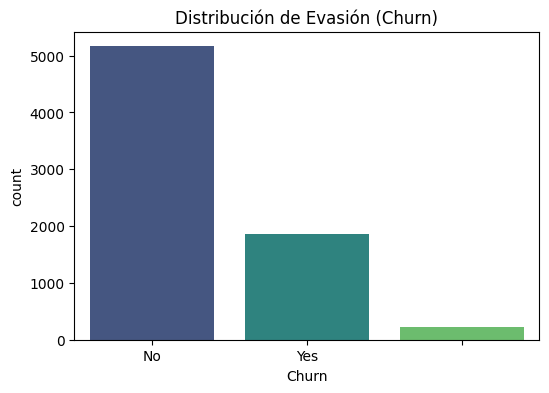

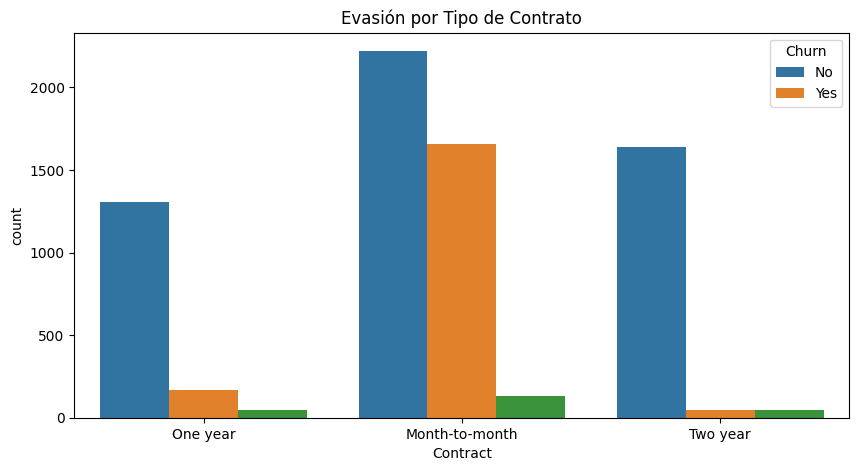

/tmp/ipykernel_173/850221503.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='tenure', hue='Churn', shade=True)


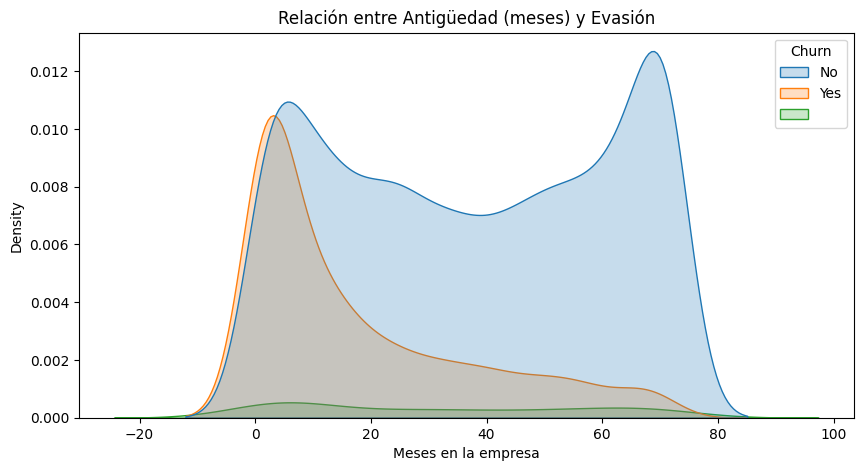

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. ¿Cómo se distribuye el Churn en la empresa?
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribución de Evasión (Churn)')
plt.show()

# 2. Análisis por tipo de contrato (Hipótesis: Los contratos cortos se van más)
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Evasión por Tipo de Contrato')
plt.show()

# 3. Análisis de Antigüedad vs Evasión
plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x='tenure', hue='Churn', shade=True)
plt.title('Relación entre Antigüedad (meses) y Evasión')
plt.xlabel('Meses en la empresa')
plt.show()

#📄Informe final

1. Hallazgos principales

    Contratos de corto plazo: La mayor tasa de abandono se concentra en clientes con contrato "Month-to-month". Esto indica una baja fidelización inicial.

    Servicios Críticos: Los clientes que utilizan Fibra Óptica presentan una tasa de evasión superior a los de DSL, lo que podría sugerir problemas de precio o estabilidad técnica en ese servicio específico.

    Facturación: El uso de "Electronic Check" como método de pago está altamente correlacionado con el Churn.

2. Razones de la Evasión

    Falta de barreras de salida: Los contratos mensuales facilitan que el cliente se vaya ante cualquier oferta de la competencia.

    Percepción de valor: Los clientes nuevos (baja antigüedad) son los más propensos a irse, lo que sugiere que la experiencia de "onboarding" o los beneficios de bienvenida no son suficientes para retenerlos a largo plazo.

3. Recomendación para Ciencia de Datos

    "Se entrega un dataset limpio con XX registros y YY variables. Se recomienda al equipo de Ciencia de Datos dar mayor peso (feature importance) a las variables de Contract, tenure y TotalCharges para el entrenamiento del modelo predictivo."